### Setting up the environment
Please make sure tkinter backend is installed if not already (`pip install PyQt5` to download the package)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

### Setting up the deep Q skeleton

In [ ]:
import torch
import copy
"""
In this section I have tried to manually create my own DQN model for each agent type. 
Each with their own online and target network. After multiple iteration of my codes, 
the results has shown that my manual implementation is not as efficient as the provided 
DQN class, as my implementation isn't as modular and efficient compared to a DQN that is 
class based. Due to this the resulting performance is inconsistent, my inefficient coding 
also plays a role in.

For the game theory aspect, in get_reward_and_new_state there is a condition that when agents of
opposite type meets in the same position while not having the secret code they will be rewarded, 
this is to incentive cooperation

The code:
# Rewards opposite agent types if they are in same position and has not exchange secret code
for a in self.agent:
    if (a.agent_type != agent.agent_type and a.position == agent.position and not self.get_exchange_secret_code()):
        reward += 5.0   

"""
grid_size = 5
statespace_size= grid_size * grid_size * 3 + 2 # 3 channels + 2 relative distance coordination

class DQN:
    def __init__(self, statespace_size, action_size=4):
        l1 = statespace_size
        l2 = 15 # 150
        l3 = 15 # 100
        l4 = action_size
        self.model_online_network = torch.nn.Sequential(
                torch.nn.Linear(l1, l2),
                torch.nn.ReLU(),
                torch.nn.Linear(l2, l3),
                torch.nn.ReLU(),
                torch.nn.Linear(l3, l4)
            )
        target_model_network = copy.deepcopy(self.model_online_network)
        target_model_network.load_state_dict(self.model_online_network.state_dict())
        self.optimizer = torch.optim.Adam(self.online_model_network.parameters(), lr=0.0001)

        self.loss_fn = torch.nn.MSELoss() 
        return target_model_network
    
    def soft_update(target_model, online_model, tau=0.001): # 0.001
        for target_param, online_param in zip(target_model.parameters(), online_model.parameters()):
            target_param.data.copy_(tau * online_param.data + (1.0 - tau) * target_param.data)

    # Get Q-values based on agent type
    def get_qvals(self, state):
        qvals_torch = self.online_model_network(state)
        return qvals_torch


team1_dqn = DQN(statespace_size)
team2_dqn = DQN(statespace_size)

### Updated epsison_policy

In [3]:
import random

def select_action_epsilon_greedy(q_values, epoch, max_epoch, start=1, end=0.05): # 0.05
    epoch = min(epoch, max_epoch)
    epsilon = start - (start - end) * (epoch / max_epoch)
    if random.random() < epsilon:
        return random.choice(range(4))
    else:
        action = torch.argmax(q_values).item()
    
    return action

### Experience Buffer class


In [ ]:
from collections import deque

class ReplayBuffer:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def __len__(self):
        return len(self.memory)

    def push(self, state, action, reward, next_state, done):
        experience_tuple = (state, action, reward, next_state, done)
        self.memory.append(experience_tuple)

    def sample(self, batch_size):
        batch = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        states_tensor = torch.stack(states)
        rewards_tensor = torch.tensor(rewards, dtype=torch.float32)
        next_states_tensor = torch.stack(next_states)
        dones_tensor = torch.tensor(dones, dtype=torch.float32)
        actions_tensor = torch.tensor(actions, dtype=torch.long).unsqueeze(1)
        return states_tensor, actions_tensor, rewards_tensor, next_states_tensor, dones_tensor
    
agent1_replay_buffer = ReplayBuffer()
agent2_replay_buffer = ReplayBuffer()
agent3_replay_buffer = ReplayBuffer()
agent4_replay_buffer = ReplayBuffer()

In [5]:
# Just passing this to stop VS code from showing that Agent is not defined
class Agent:
    pass

### Simulation class

This class provides the functionality to initialise a grid world, manage an agent's interactions within the world, implement the Q-learning algorithm for the agent to learn the optimal paths to achieve its goal (pick up and drop off Item A) and real-time visualisation of the grid world and the agent's action using matplotlib.

In [ ]:
from scipy.signal import savgol_filter

class Simulation:
    """Simulaation class for modeling, simulating and visualising an agent in a grid-based environment.

    This class provides the functionality to initialise a grid world, manage an agent's interactions within the world, implement the Q-learning algorithm for the agent to learn the optimal paths to achieve its goal (pick up and drop off Item A) and real-time visualisation of the grid world and the agent's action using matplotlib.
    
    Attributes:
        grid_size (int): The size of the square grid.
        goalA (tuple[int,int]): The coordinates of the pickup location in the grid. Defaults to None. This coordinate is randomly generated during initialisation.
        goalB (tuple[int,int]): The coordinates of the dropoff location in the grid. Defaults and fixed to be the bottom most right tile on the grid.
        is_pickup (bool): A boolean indicating whether the agent has pickup the item from goalA.
        world (np.ndarray): The grid world represented using a 2D numpy array.
        agent (Agent): The agent in the simulation.
        eppoch_rewards (list): A list to store the total rewards obtained in each epoch during training.
        avg_rewards_by_epoch (list): A list to store the total rewards obtained in each epoch during training.
        direction_index (dict): A dictionary used for to determine the index when onehot encoding the direction of the goal relative to the agent.
        cbar (matplotlib.colorbar.Colorbar): The colorbar used in the matplotlib grid world visualisation to indicate what each color represents.
    """
    def __init__(self, grid_size :int = grid_size) -> None:
        """Initialise a simulation instance.

        Args:
            grid_size (int, optional): The size of the square grid world .Defaults to 5.
        """
        self.grid_size = grid_size
        self.goalA = None
        self.goalB = None
        self.is_pickup = False
        self.world = np.zeros([self.grid_size, self.grid_size])
        self.agent = None
        self.training_history = []
        self.eppoch_rewards = []
        self.avg_rewards_by_epoch = []
        self.directional_index = {
            "up": 0,
            "down": 1,
            "left": 2,
            "right": 3,
        }

        self.cbar = None
        
        
    def initialise_world(self) -> None:
        """Initialise the grid world

        Initialise the grid world then assign the bottom most right tile with a value of 3 to indicate the 
        drop off location. Then randomly assigned a tile on the grid as pick up location while making sure 
        that drop off and pickup location is different. The pickup location on the grid world is represented 
        with a value of 2. Finally, initialise an agent using the Agent class with a random x and y coordinate. 
        On the grid world, the agent is represented with a value of 1.
        
        Initializing grid world with random location of goalA (pickup location/item) and goalB (dropoff location/goal).
        Checks are put in place to ensure that pickup and dropoff location are different. 
        """
        self.goalB = (
                np.random.randint(0, self.grid_size),
                np.random.randint(0, self.grid_size),
        )
        self.world[self.goalB] = 3

        # This is to make sure dropoff and pickup location are different
        while self.goalA is None or self.goalA == self.goalB:
            self.goalA = (
                np.random.randint(0, self.grid_size),
                np.random.randint(0, self.grid_size),
            )
            
        # Place pick up location to the grid world
        self.world[self.goalA] = 4
                
        total_agents = 4
        self.agent = []
        
        # Variable to store creation of agents
        taken_pos = set()

        # Iterate through total_agents
        for count in range(total_agents):
              
            # Setting agent type 1 and 2
            agent_type = 1 if count < 2 else 2
            while True:
                position = (np.random.randint(0, self.grid_size), np.random.randint(0, self.grid_size))
                
                # Check if position has not been taken by another agent, goalB or goalA
                if position not in taken_pos and position != self.goalB and position != self.goalA:
                    break
            
            # Initializing agent with agent type and position
            agent = Agent(agent_type=agent_type, position=position)
            self.agent.append(agent)
            taken_pos.add(position)
            
            # Placing the agents initialized in the world
            for agent in self.agent:
                if agent.agent_type == 1:
                    self.world[agent.position] = 1
                else:
                    self.world[agent.position] = 2
      
    def get_goal_direction(self, agent) -> str:
        
        """Get goal direction relative to agent's position

        Determine the direction of the goal relative to the agent's position by comparing the goal and agent's 
        coordinate.

        Returns:
            str: The direction of the goal relative to agent's position
        """
        if self.is_pickup:
            goal = self.goalB
        else:
            goal = self.goalA
            
        if agent.position[1] == goal[1]:  # Same y coordinate
            if agent.position[0] > goal[0]:
                return "up"
            else:
                return "down"

        elif agent.position[0] == goal[0]:  # Same x coordinate
            if agent.position[1] > goal[1]:
                return "left"
            else:
                return "right"
        
    # Calculating distance between agent and opposite agent type using euclidean distance
    def calculate_distance(self, pos_agent_1, pos_agent_2):
        return ((pos_agent_1[0] - pos_agent_2[0]) ** 2 + (pos_agent_1[1] - pos_agent_2[1]) ** 2) ** 0.5
    
    def get_closest_opposite_agent_type(self, agent):
        """
        By "purchasing option of Sensors Closest agent of opposite type (direction to)", this augments
        observation space for the closest agent by finding the direction to it. 

        Args:
            agent (Agent): Current agent that wants to find the closest agent of opposite type.

        Returns:
            Tuple[Agent, float, Tuple[int, int]]: 
            - cloeset_opposite_agent (Agent): Closest opposite agent type
            - min_distance (float): Distance to closest opposite agent type
            - direction_to (Tuple[int, int]): Tuple of direction vector of the current agent to the closest opposite agent type
        """
        # Variable for comparison
        closest_opposite_agent = None
        min_distance = float('inf')
        direction_to = None

        for near_to in self.agent:
            
            # Wehn closest agent is opposite type
            if near_to.agent_type != agent.agent_type:
                
                # Calculate the distance between the two
                distance = self.calculate_distance(near_to.position, agent.position)

                # If shorter distance has been found
                if distance < min_distance:
                    
                    # Update min_distance
                    min_distance = distance
                    
                    # Place the nearest opposite agent type found (near_to) as closest_opposite_agent
                    closest_opposite_agent = near_to
                    
                    # Calculating direction to using (otherPos - myPos)
                    direction_to = (near_to.position[0] - agent.position[0], near_to.position[1] - agent.position[1])

        return closest_opposite_agent, min_distance, direction_to

    def get_direction_to_opposite_agent_type(self, agent, opposite_agent_type):
        """Get opposite agent type direction relative to agent's position

        Determine the direction of the opposite agent type relative to the agent's position 
        by comparing the opposite agent type and agent's coordinate.

        Returns:
            str: The direction of the opposite agent type relative to agent's position
        """

        if agent.position[1] == opposite_agent_type.position[1]: # Same y coordinate
            if agent.position[0] > opposite_agent_type.position[0]:
                return "up"
            else:
                return "down"
            
        elif agent.position[0] == opposite_agent_type.position[0]:  # Same x coordinate
            if agent.position[1] > opposite_agent_type.position[1]:
                return "left"
            else:
                return "right"

    def encode_one_hot_direction(self, direction: str):
        
        one_hot_direction = {
            'up': 0,
            'down': 1,
            'left': 2,
            'right': 3,
        }
        
        if direction in one_hot_direction:
            one_hot_direction_to_tensor = torch.zeros(len(one_hot_direction))
            one_hot_direction_to_tensor[one_hot_direction[direction]] = 1
        else:
            raise ValueError(
                f"Direction returned is unknown: {direction}"
            )
        
        return one_hot_direction_to_tensor
    
    def convert_world_state_to_network_input_tensor(self, agent) -> torch.Tensor:
        """ Convert world state information into input tensor for neural network. """

        # Current direction towards the goal (goalA or goalB)
        direction_channel = np.zeros(len(self.directional_index))
        goal_direction = self.get_goal_direction(agent)
        if goal_direction in self.directional_index:
            direction_channel[self.directional_index[goal_direction]] = 1

        # Initialize channels
        agent_channel = np.zeros((self.grid_size, self.grid_size))
        pickup_channel = np.zeros((self.grid_size, self.grid_size))
        dropoff_channel = np.zeros((self.grid_size, self.grid_size))

        # Mark agent's current position
        if agent.agent_type == 1:
            agent_channel[agent.position] = 1
        else:
            agent_channel[agent.position] = 2

        # Set pickup channel
        pickup_channel[self.goalA] = 1 if not self.is_pickup else 0

        # Set dropoff channel
        dropoff_channel[self.goalB] = 1

        # Concatenate input tensor
        input_tensor1 = torch.flatten(torch.tensor(np.stack([agent_channel, pickup_channel, dropoff_channel]), dtype=torch.float32))

        input_tensor = torch.cat([torch.tensor(direction_channel, dtype=torch.float32), input_tensor1]).type(torch.float32)

        # Get closest opposite agent information
        closest_opposite_agent, _, direction_to = self.get_closest_opposite_agent_type(agent)
        if direction_to is not None:
            direction_tensor = torch.tensor(direction_to, dtype=torch.float32)
        else:
            direction_tensor = torch.zeros(2, dtype=torch.float32)

        final_state = torch.cat((input_tensor, direction_tensor), dim=0)

        return final_state

    def get_reward_and_new_state(self, agent, actions: list[int]) -> float:
        """
        Calculate the reward obtained based on the agent's action.

        This function calculates the reward obtained by the agent based on its action.
        It then calculates the reward based on the agent's current position and whether 
        it has picked up an item or not.
        Penalty has been set to be lower to encourage exploration, when high penalty were 
        tested it is not that efficient. My understanding is that with high penalty agents are 
        discourage to explore better pathways. High penalty also negatively affects the early learning
        process of agents

        Args:
        action (int): The action which the agent took

        Returns:
        float: The reward associated to the agent's action.
        """
        total_reward = 0
        
        for i, agent in enumerate(self.agent):
            # next_x, next_y = agent.get_new_state(actions[i])
            # next_pos.append(next_x, next_y)
            # saving old state
            old_state = agent.position

            # moving agent based on action
            agent.get_new_state(actions)

            # base move cost
            reward = -0.1 

            # Check if agent moved out of bound. If so reset its position back to its previous position.
            if not (0 <= agent.position[0] < self.grid_size) or not (0 <= agent.position[1] < self.grid_size):
                agent.position = old_state  
                # to discourage moving out of bound
                reward = -2.0
                
            # Check if agent is moving to the same position of similar agent type, if so reset back to previous position
            elif self.world[agent.position] == agent.agent_type:
                agent.position == old_state
                reward = -1.0
            else:
                # Rewards opposite agent types if they are in same position and has not exchange secret code
                for a in self.agent:
                    if (a.agent_type != agent.agent_type and a.position == agent.position and not self.get_exchange_secret_code()):
                        reward += 5.0                        
                    
            # Checking for not is_pickup while agent is at is_pickup position
            if not self.is_pickup and agent.position == self.goalA:
                reward += 20.0  # 5.0 reward for reaching pickup location
                self.is_pickup = True  # Set pickup flag when reaching goalA

            # Second check only for when agent is not is_pickup, this is separated to avoid logical flaw
            elif not self.is_pickup:
                if agent.position == self.goalB:
                    reward -= 0.5  # 0.5 Increased penalty for reaching dropoff location without item
                elif old_state == agent.position:
                    reward -= 0.5  # 0.5 Penalty for hitting a wall
                else:
                    # Calculate distance to goalA                   
                    old_distance = ((old_state[0] - self.goalA[0]) ** 2 + (old_state[1] - self.goalA[1]) ** 2) ** 0.5
                    new_distance = ((agent.position[0] - self.goalA[0]) ** 2 + (agent.position[1] - self.goalA[1]) ** 2) **0.5
                    
                    if new_distance < old_distance:
                        reward += 10.0  # 0.2 Small reward for moving closer to goalA
                    elif new_distance > old_distance:
                        reward -= 2.0  # 0.4 Double penalty for moving away from goalA
                        
            elif agent.position == self.goalB and not agent.exchange_secret_code:
                reward -=  3.0 # 3.0
            else:
                if agent.position == self.goalB and agent.exchange_secret_code:
                    reward += 100.0  # 15.0 Increased reward for reaching drop off location with item
                else:
                    # Calculate distance to goalB
                    old_distance = ((old_state[0] - self.goalA[0]) ** 2 + (old_state[1] - self.goalA[1]) ** 2) ** 0.5
                    new_distance = ((agent.position[0] - self.goalA[0]) ** 2 + (agent.position[1] - self.goalA[1]) ** 2) **0.5
                    
                    if new_distance < old_distance:
                        reward += 15.0 # 0.2 Small reward for moving closer to goalB
                    elif new_distance > old_distance:
                        reward -= 0.5 # 0.4 Double penalty for moving away from goalB
                    
                    if old_state == agent.position:
                        reward -= 0.1 # 0.5 Penalty for hitting a wall
            total_reward += reward
         
        return total_reward
                
    def get_exchange_secret_code(self):
        """
        Checks if current agent and opposite agent are on same position. Exchange secret code if they are 
        
        Attributes:
        agent_type1 (Agent): Type 1 Agent
        agent_type2 (Agent): Type 2 Agent
        
        """
        for agent_type1 in self.agent:
            for agent_type2 in self.agent:
                
                # When agent type is opposite and at the same position, set exchange_secret_code to True
                if agent_type1.agent_type != agent_type2.agent_type and agent_type1.position == agent_type2.position:
                    
                    # Set exchange_secret_code to True 
                    agent_type1.exchange_secret_code = True
                    agent_type2.exchange_secret_code = True
                    # print(f"Agent {agent_type1.agent_type} met with Agent {agent_type2.agent_type}. Both can now access goalB.")
    
    def step(self, actions) -> tuple[float, bool]:
        total_reward = 0
        is_done = False

        # Store old positions for all agents
        old_positions = [agent.position for agent in self.agent]
        
        # Calculate new positions based on actions without modifying `world` directly
        next_positions = []

        # Loop to get new position for all agents without updating yet
        for i, agent in enumerate(self.agent):
            action = actions[i]
            
            # Get next set of position from agent's action
            next_x, next_y = agent.get_new_state(action)  
            
            # Store in next_position 
            next_positions.append((next_x, next_y))
        
        # Next loop to update position with collision check, to prevent overwriting of positions
        for i, agent in enumerate(self.agent):
            final_position = next_positions[i]

            # Check other agents for position and type, stops 2 agent of same type to be in same position
            if any(a.position == final_position and a.agent_type == agent.agent_type for a in self.agent if a != agent):
                # print(f"Agent {i} tried to move to an occupied position: {final_position}")
                # if anything True it stops
                continue  
                
            # Set the agent's position as the proper final position after checks
            agent.position = final_position
            # print(f"Agent {i} moved to {agent.position} by taking action {actions[i]}")

            # Calculate rewards
            reward = self.get_reward_and_new_state(agent, actions[i])
            total_reward += reward

            # Check if the agent reached goal A
            if agent.position == self.goalA:
                self.is_pickup = True

            # Check for goal B conditions
            self.get_exchange_secret_code()
            if agent.position == self.goalB and self.is_pickup and agent.exchange_secret_code:
                is_done = True

        return total_reward, is_done
     
    def agent_explore_or_exploit_action(self, agent_choice, index) -> int:
        # @deprecated, see select_action_epsilon_greedy() above
        pass

    def initialise_q_learning(self) -> None:
        """Initialise the grid  world

        This method prepares the simulation for Q-learning by calling the  initialise_world method to initialise the grid world, include setting up the agent's starting position together with the pick up and drop off location. It also calls the convert_world_state_to_network_input_tensor method to generate the initial 
        
        
        ,  which  will be used to store the state-action values for Q-learning.
        """
        # Initialise the world
        self.initialise_world()
           
    def training(
        self,
        training_epoch_count: int = 500, 
        max_steps: int = 25,
        gamma: float = 0.90, 
        sample_size=10000,
        batch_size=64, 
        visualise: bool = False,
        eval_frequency: int = 50,
        max_eval_steps: int = 15
    ) -> None:
        replay_buffer = ReplayBuffer(sample_size)  # 10000 samples to randomly learn from
        prepare_torch()

        if visualise:
            self.visualise_world()
            plt.pause(0.5)

        for epoch in range(training_epoch_count):
            done = False
            episode_reward = 0
            loss_this_epoch = None

            if epoch != 0:
                self.reset()
            
            for step in range(max_steps):
                if visualise:
                    self.update_grid()
                    plt.pause(0.5)

                actions = []
                for agent in self.agent:
                    # Get the action for each agent
                    curr_x, curr_y = agent.position
                    old_state = self.convert_world_state_to_network_input_tensor(agent)
                    q_values_for_action_selection = get_qvals(old_state, agent.agent_type)
                    action = select_action_epsilon_greedy(q_values_for_action_selection, epoch, training_epoch_count)
                    actions.append(action)
                
                reward, done = self.step(actions)

                next_positions = []
                for i, agent in enumerate(self.agent):
                    # Get the next position based on the action while considering grid boundaries
                    next_x, next_y = agent.get_new_state(actions[i])
                    next_positions.append((next_x, next_y))

                    # Add the experience to replay buffer
                    next_state = self.convert_world_state_to_network_input_tensor(agent)
                    replay_buffer.push(old_state, action, reward, next_state, done)

                    if len(replay_buffer) >= 10000:
                        states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
                        if agent.agent_type == 1:
                            # Training code for agent type 1
                            max_q_value_for_training = agent_type1_online_model(states).gather(1, actions).squeeze(1)
                            
                            # Ensure gradients are not tracked for TARGET network
                            with torch.no_grad():
                                # always choose the EXPLOIT path for the target Q values
                                max_next_q_values = get_maxQ_from_target_network(next_states, agent.agent_type)
                                # Obtain the ideal Q-values, from TARGET
                                # (1-dones) to account for terminal states. If done, then just get the reward only
                                target_q_values = rewards + gamma * max_next_q_values * (1-dones)
                            
                            # calculate loss between ONLINE and TARGET predictions
                            loss = loss_fn(max_q_value_for_training, target_q_values)
                            
                            # Optimize the online network for type 1 agents
                            optimizer_type1.zero_grad()
                            loss.backward()
                            # help stablize the training process
                            torch.nn.utils.clip_grad_norm_(agent_type1_online_model.parameters(), max_norm=1.0)
                            optimizer_type1.step()
                            loss_this_epoch = min(loss.item(), loss_this_epoch) if loss_this_epoch is not None else loss.item()
                        
                        elif agent.agent_type == 2:
                            # Training code for agent type 2
                            max_q_value_for_training = agent_type2_online_model(states).gather(1, actions).squeeze(1)
                            # Ensure gradients are not tracked for TARGET network
                            with torch.no_grad():
                                # always choose the EXPLOIT path for the target Q values
                                max_next_q_values = get_maxQ_from_target_network(next_states, agent.agent_type)
                                # Obtain the ideal Q-values, from TARGET
                                # (1-dones) to account for terminal states. If done, then just get the reward only
                                target_q_values = rewards + gamma * max_next_q_values * (1-dones)
                            
                            # calculate loss between ONLINE and TARGET predictions
                            loss = loss_fn(max_q_value_for_training, target_q_values)
                            
                            # Optimize the online network for type 2 agents
                            optimizer_type2.zero_grad()
                            loss.backward()
                            # help stablize the training process
                            torch.nn.utils.clip_grad_norm_(agent_type2_online_model.parameters(), max_norm=1.0)
                            optimizer_type2.step()
                        
                        loss_this_epoch = min(loss.item(), loss_this_epoch) if loss_this_epoch is not None else loss.item()
                    episode_reward += reward
                if done:
                    if visualise:
                        self.update_grid()
                        plt.pause(0.5)
                    self.training_history.append(step)
                    if step > 0:
                        self.avg_rewards_by_epoch.append(episode_reward / step)
                    break

            if epoch % 50 == 0:
                soft_update(agent_type1_target_model, agent_type1_online_model)
                soft_update(agent_type2_target_model, agent_type2_online_model)

            if epoch % 50 == 0:
                if step > 0:
                    print(f'-------------avg rewards: {episode_reward / step} at epoch {epoch} of {training_epoch_count}')
                else:
                    print(f'-------------avg rewards: 0 at epoch {epoch} of {training_epoch_count}')

        plt.close()

    def reset(self) -> None:
        """Reset the simulation and reinitialize a new environment.

        This method resets the current state of the grid world by resetting it to a zero matrix 
        and reinitializing a new environment (pickup and drop-off locations). 
        The agents are kept, but their positions can be reset if needed.
        """
        self.world = np.zeros([self.grid_size, self.grid_size])
        self.is_pickup = False
        
        # Reinitialize goals and assign them to the world
        self.goalB = (np.random.randint(0, self.grid_size), np.random.randint(0, self.grid_size))
        self.world[self.goalB] = 3

        # Reinitialize goalA/goalB (item and goal) without being in same place
        while True:
            self.goalA = (np.random.randint(0, self.grid_size), np.random.randint(0, self.grid_size))
            if self.goalA != self.goalB:
                break
        self.world[self.goalA] = 4

        # Ensure goalA and goalB are same position
        taken_pos = set([self.goalA, self.goalB])  # Keep track of goal positions
        
        for agent in self.agent:
            while True:
                
                # Give agents new random position
                next_position = (np.random.randint(0, self.grid_size), np.random.randint(0, self.grid_size))
                
                # Check agent's new random position with goalA and goalB, break if same
                if next_position not in taken_pos:
                    break
                
            # Set agent's new random position
            agent.position = next_position  
            
            # Add agent's new random position in taken_pos to ensure they are not in same position
            taken_pos.add(next_position)
            
            # Place agents in the grid world
            # if agent.agent_type == 1:
            #     self.world[agent.position] = 1
            # else:
            #     self.world[agent.position] = 2
            self.world[agent.position] = agent.agent_type
            
    def visualise_world(self) -> None:
        """Visualize the initial grid world."""
        # Enable interactive mode
        plt.ion()
        self.fig, self.ax = plt.subplots()
        color_list = ["white", "blue", "red", "orange", "green"]
        cmap = ListedColormap(color_list)
        self.ax.set_title("Simulated Grid World")
        self.grid_img = self.ax.imshow(self.world, cmap=cmap)
        self.ax.grid(True, which="both", color="black", linestyle="-", linewidth=1)
        self.ax.set_xticks(np.arange(-0.5, len(self.world), 1), [])
        self.ax.set_yticks(np.arange(-0.5, len(self.world), 1), [])
        self.ax.set_xticks(np.arange(-0.5, self.world.shape[1], 1), minor=True)
        self.ax.set_yticks(np.arange(-0.5, self.world.shape[0], 1), minor=True)

        # Create the colorbar once
        self.cbar = plt.colorbar(self.grid_img, ticks=[0, 1, 2, 3, 4], ax=self.ax)
        self.cbar.ax.set_yticklabels(
            ["Empty", "Agent type 1", "Agent type 2", "Pickup Loc", "Dropoff Loc"]
        )

        plt.show(block=False)
    
    def visualise_world(self) -> None:
        """Visualize the initial grid world."""
        plt.ion()  # Enable interactive mode
        self.fig, self.ax = plt.subplots()
        color_list = ["white", "blue", "red", "orange", "green"]
        cmap = ListedColormap(color_list)
        self.ax.set_title("Simulated Grid World")
        self.grid_img = self.ax.imshow(self.world, cmap=cmap)
        self.ax.grid(True, which="both", color="black", linestyle="-", linewidth=1)
        self.ax.set_xticks(np.arange(-0.5, len(self.world), 1), [])
        self.ax.set_yticks(np.arange(-0.5, len(self.world), 1), [])
        self.ax.set_xticks(np.arange(-0.5, self.world.shape[1], 1), minor=True)
        self.ax.set_yticks(np.arange(-0.5, self.world.shape[0], 1), minor=True)

        # Create the colorbar once
        self.cbar = plt.colorbar(self.grid_img, ticks=[0, 1, 2, 3, 4], ax=self.ax)
        self.cbar.ax.set_yticklabels(
            ["Empty", "Agent type 1", "Agent type 2", "Pickup Loc", "Dropoff Loc"]
        )
        plt.show(block=False)
        
    def update_grid(self) -> None:
        """Update grid world visualization to the current state."""
        self.grid_img.set_data(self.world)
        self.grid_img.autoscale()  # Optional: Adjusts the scaling if needed
        self.fig.canvas.draw_idle()  # Efficiently redraws the canvas
        self.fig.canvas.flush_events()  # Ensures all events are processed

    def plot_training_history_step(self) -> None:
        """
        Plots the training history with a smoothed curve

        This function generates a line plot using matplotlib to visualize the training history. The x-axis represents the epoch number, and the y-axis represents the total number of steps taken in each epoch until the epoch ended.
        """
        # Original plot
        plt.figure(figsize=(10, 5))
        plt.plot(self.training_history, label='Original', alpha=0.5)

        # Smooth the curve using Savitzky-Golay filter
        smoothed_steps = savgol_filter(self.training_history, window_length=51, polyorder=3)
        
        plt.plot(smoothed_steps, color='red', label='Smoothed Curve')
        plt.xlabel("Epoch")
        plt.ylabel("Total steps")
        plt.title("Total steps taken per epoch during training")
        plt.legend()
        plt.show(block=False)

        
    def plot_training_history_rewards(self) -> None:
        """
        Plots the average rewards obtained per epoch during training.

        This function generates a line plot of the total rewards obtained per epoch during the training of the Q-learning agent. The x-axis represents the epoch number, and the y-axis represents the total rewards obtained in that epoch.
        """
        plt.figure(figsize=(10, 5))
        plt.plot(self.avg_rewards_by_epoch)
        plt.xlabel("Epoch")
        plt.ylabel("Avg Rewards")
        plt.title("Avg rewards per epoch during training")
        plt.show(block=False)
        
    def bfs_shortest_path(self, start, goal, grid_size):
        """
        Finds the optimal/shortest path between start and goal position
        
        """
        
        # Define the possible movements (up, down, left, right)
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        queue = deque([(start, 0)])  # Queue to store positions and steps taken so far
        visited = set([start])

        while queue:
            current_pos, steps = queue.popleft()

            # If goal is reached, return the number of steps
            if current_pos == goal:
                return steps

            # Explore neighbors
            for direction in directions:
                next_pos = (current_pos[0] + direction[0], current_pos[1] + direction[1])

                # Check if next position is within the grid and not visited
                if (0 <= next_pos[0] < grid_size and
                    0 <= next_pos[1] < grid_size and
                    next_pos not in visited):
                    
                    queue.append((next_pos, steps + 1))
                    visited.add(next_pos)

        # If no path is found, return a large value or infinity
        return float('inf')
    
    def visualise_training(self, 
                       training_epoch_count: int=10, 
                       max_steps: int=50, 
                       sample_size=10000, 
                       visualise: bool=True, 
                       pause_duration: float=0.5,
                       end_visualise: int = 5) -> None:
            """
            Visualize the Q-learning agent training process.
            
            Args:
                training_epoch_count (int): Number of training epochs. Default is 2000.
                max_steps (int): Maximum number of steps per epoch. Default is 25.
                gamma (float): Discount factor for future rewards. Default is 0.99.
                sample_size (int): Number of experiences to store in the replay buffer. Default is 10000.
                batch_size (int): Number of samples to use for training the model in one batch. Default is 64.
                visualise (bool): If True, visualizes the training process. Default is True.
                pause_duration (float): Duration to pause after each visualization update. Default is 0.5.
            
            Returns:
                None
            """
            replay_buffer = ReplayBuffer(sample_size)
            prepare_torch()

            # Initialize visualization if visualise flag is True
            if visualise:
                fig, ax = plt.subplots()
                ax.set_title("Training Visualization - Multi-Agent Grid World")
                plt.ion()  # Turn on interactive mode

            # Begin training loop
            for epoch in range(training_epoch_count):
                done = False
                step = 0
                episode_reward = 0
                
                # Store excess path length for all cases
                excess_path = 0  
                # Store number of cases tracked
                num_of_cases = 0     
                
                
                initial_positions = [agent.position for agent in self.agent]
                
                # Reset environment at the start of each epoch
                self.reset()
                
                for step in range(max_steps):
                    actions = []
                    old_positions = []

                    for agent in self.agent:
                        # Record the agent's old position
                        old_positions.append(agent.position)
                        
                        # Convert the current world state to tensor input
                        old_state = self.convert_world_state_to_network_input_tensor(agent)
                        
                        # Get Q-values for the current state
                        q_values = get_qvals(old_state, agent.agent_type)
                        
                        # Select an action using epsilon-greedy strategy
                        action = select_action_epsilon_greedy(q_values, epoch, training_epoch_count)
                        
                        # Append the chosen action for each agent
                        actions.append(action)

                    # Take actions and receive rewards and done flags
                    reward, done = self.step(actions)
                    
                    # Store old state, action, reward, next state, and done status in replay buffer
                    for i, agent in enumerate(self.agent):
                        next_state = self.convert_world_state_to_network_input_tensor(agent)
                        replay_buffer.push(old_state, actions[i], reward, next_state, done)
                        
                        start = initial_positions[i]
                        goal = self.goalB

                        # Get the optimal number of steps using BFS
                        optimal_steps = self.bfs_shortest_path(start, goal, self.grid_size)
                        
                        # Use `step` as the number of steps taken by the agent to reach the goal
                        steps_taken = step if done else max_steps

                        # Calculate the excess path length for this case
                        excess_path_length = steps_taken - optimal_steps
                        excess_path += excess_path_length
                        num_of_cases += 1

                    # Update the grid visualization after each agent step
                    if visualise and epoch < 3:
                        self.visualising_training_grid(ax, epoch, step)
                        plt.pause(pause_duration)

                    # Check for terminal state
                    if done:
                        break
                
                # Update neural networks and perform soft updates for target networks
                # if visualise and epoch % 50 == 0:
                #     print(f'Average rewards: {episode_reward / max(1, step)} at epoch {epoch}/{training_epoch_count}')
                    # Calculate average excess path length
            average_excess_path_length = excess_path / num_of_cases if num_of_cases > 0 else float('inf')

            print(f"Average Excess Path Length: {average_excess_path_length}")
            
            if visualise:
                plt.ioff()  # Turn off interactive mode
                plt.show()
    
    def visualising_training_grid(self, ax, epoch, step):
        """
        Update the visualization of the grid with agents, goals, and information.
        
        Args:
            ax (plt.Axes): The axes to update.
            epoch (int): Current epoch in training.
            step (int): Current step in epoch.
            episode_reward (float): Cumulative reward for the episode.
        
        Returns:
            None
        """
        # Clear everything
        ax.clear()
        
        # Get grid size
        world_size = self.world.shape
        data = np.zeros(world_size)
        
        # Loop through and place agents in their respective positions
        for agent in self.agent:
            x, y = agent.position
            data[x, y] = agent.agent_type
        
        # Display goals visually
        goalA_x, goalA_y = self.goalA
        goalB_x, goalB_y = self.goalB
        data[goalA_x, goalA_y] = 3  
        data[goalB_x, goalB_y] = 4 
        
        # Create a colormap to distinguish agents and goals, goalA is orange, goalB is green
        color_list = ["gray", "blue", "red", "orange", "green"]
        cmap = ListedColormap(color_list)
        

        # Show the grid using imshow
        ax.imshow(data, cmap=cmap, vmin=0, vmax=4)
        
        # Display text with current training status
        ax.set_title(f"Epoch: {epoch} | Step: {step}")
        ax.set_xlabel("Grid World (column)")
        ax.set_ylabel("Grid World (row)")    
    
    @staticmethod
    def get_all_symmetries(grid):
        """Returns symmetric versions of the given grid (rotations and reflections)."""
        # Ensure grid is a 2D array
        if not isinstance(grid, np.ndarray) or grid.ndim != 2:
            raise ValueError("Grid must be a 2D numpy array.")

        symmetries = []
        # Original
        symmetries.append(grid)
        # Rotations
        symmetries.append(np.rot90(grid, k=1)) # 90
        symmetries.append(np.rot90(grid, k=2)) # 180
        symmetries.append(np.rot90(grid, k=3)) # 270
        # Reflections 
        symmetries.append(np.fliplr(grid)) # horizontal
        symmetries.append(np.flipud(grid)) # vertical
        return symmetries

    @staticmethod
    def get_canonical_form(grid):
        """Returns the canonical form of the grid by finding the lexicographically smallest symmetry."""
        # Ensure that the input grid is a numpy array
        if not isinstance(grid, np.ndarray):
            print(grid)
            print(np.ndarray)
            grid = np.array(grid)

        # Check if the grid is 2D
        if grid.ndim != 2:
            raise ValueError("Grid must be a 2D numpy array.")
        
        # get all symmetric version of the grid
        symmetries = Simulation.get_all_symmetries(grid)
            # Print out all symmetries for debugging
        # print("Symmetries:")
        # for sym in symmetries:
        #     print(sym)

        # Find the lexicographically smallest version of the grid
        canonical_form = min(symmetries, key=lambda x: x.flatten().tobytes())
        # print(f'Canonical form {canonical_form}')
        
        return canonical_form

    # # Example usage
    # grid = np.array([
    #     [0, 1, 0, 0, 2],
    #     [0, 0, 0, 3, 0],
    #     [4, 0, 0, 0, 0],
    #     [0, 0, 5, 0, 0],
    #     [0, 0, 0, 0, 0]
    # ])

    # canonical_grid = get_canonical_form(grid)
    # print(canonical_grid)
        

    def evaluate_performance(self, num_episodes: int = 200000, max_steps: int = 25) -> float:
        """
        Evaluate the performance of the agents while reducing redundant symmetric scenarios.
        
        Args:
            num_episodes (int, optional): Number of evaluation episodes. Defaults to 10.
            max_steps (int, optional): Maximum number of steps per episode. Defaults to 25.

        Returns:
            float: Performance level as a percentage.
        """
        best_steps = float('inf')
        eval_less_than_15 = 0
        seen_configs = set()  # Set to store canonical versions of scenarios already evaluated

        # Run the agent for a number of test episodes
        for episode in range(num_episodes):
            # Reset the environment for each episode
            self.reset()
            done = False
            steps_taken = 0

            # Get the initial grid state and compute its canonical form
            initial_grid = self.world.copy()  # Assuming `self.world` holds the state of the environment
            canonical_grid = Simulation.get_canonical_form(initial_grid)
            canonical_bytes = canonical_grid.tobytes()  # Convert to hashable format

            # Skip if the scenario has been seen before
            if canonical_bytes in seen_configs:
                print(seen_configs)
                print(canonical_bytes)
                print(len(seen_configs))
                continue  # Skip this episode since it's equivalent to one already evaluated

            # Otherwise, add to seen configurations
            seen_configs.add(canonical_bytes)

            # Step through the environment until max_steps or goal is reached
            for step in range(max_steps):
                actions = []
                for agent in self.agent:
                    # Get the agent's action using the trained policy
                    state = self.convert_world_state_to_network_input_tensor(agent)
                    q_values = get_qvals(state, agent.agent_type)
                    action = torch.argmax(q_values).item()  # Choose the action with the highest Q-value
                    actions.append(action)

                # Perform the action
                _, done = self.step(actions)
                steps_taken += 1

                # Stop if the goal is reached
                if done:
                    break

            # Check if the goal was reached within 15 steps
            if done and steps_taken < 15:
                eval_less_than_15 += 1

            # Update the best case scenario if this episode is more optimized
            if done and steps_taken < best_steps:
                best_steps = steps_taken

        # Calculate the performance
        performance = (eval_less_than_15 / num_episodes) * 100
        print(f"Performance Level: {performance}% of scenarios solved in less than 15 steps")

        return performance




In [7]:
class Agent:
    """ Agent class for modeling agent's decision and movement.

    This class provides the functionality to create an agent for the simulation and is responsible for handling the agent's decision whether to explore or exploit as well as moving and updating the agent's position based on the action it took.
    
    Attributes:
        position (tuple[int, int]): The agent's current (x,y) position in the grid world.
        action_dict (Dict[str, int]): A dictionary consist of all the permissible action which the agent can perform. 
        agent_type (int): Signifies the agent type, type 1 or
    """
    def __init__(self, agent_type, position: tuple[int,int]) -> None:
        """ Initialise an agent
        
        Args:
            position (tuple[int,int]): The x,y coordinate of the agent on the grid.
        """
        self.position = position
        self.action_dict = {"up": 0, "down": 1, "left": 2, "right": 3}
        self.agent_type = agent_type
        self.exchange_secret_code = False

    def get_new_state(self, action: int) -> tuple:
        """Calculate agent's new position based on the action it took.

        This function calculates the agent's new x and y coordinates on the grid base on the action taken by the agent.
        
        Agent's action information:
        - Down = 0
        - Up = 1
        - Left = 2
        - Right = 3

        Args:
            action (int): The action taken by the agent

        Raises:
            ValueError: The error raised when the action provided is not with 0 - 4.
        """
        
        # Check if action passed in is a permissible action which the agent can carry out.
        if action not in list(self.action_dict.values()):
            raise ValueError(
                f"Action only takes up, down, left, right but an invalid action '{action}' was provided"
            )
        # print(f"Agent is at position {self.position} before action")
        current_x, current_y = self.position

        # Calculate new position based on the action
        match action:
            case 0:  # Move up
                next_x = max(current_x - 1, 0)
                next_y = current_y
            case 1:  # Move down
                next_x = min(current_x + 1, 5 - 1)
                next_y = current_y
            case 2:  # Move left
                next_x = current_x
                next_y = max(current_y - 1, 0)
            case 3:  # Move right
                next_x = current_x
                next_y = min(current_y + 1, 5 - 1)
            case _:
                raise ValueError(f"Invalid action '{action}' provided.")

        return next_x, next_y    
        

### Start the simulation and train the agent

In [ ]:
# Configure matplotlib to use tkinter backend (pip install PyQt5 to download the package)
%matplotlib tk

visualise_training = False

sim = Simulation()
sim.initialise_q_learning()
sim.training(visualise=visualise_training)
sim.evaluate_performance()  # Evaluate performance

initial_grid = sim.world.copy() 
canonical_grid = Simulation.get_canonical_form(initial_grid) 

print("Testing commit")   

-------------avg rewards: 174.66666666666666 at epoch 0 of 500
-------------avg rewards: 3.1500000000000057 at epoch 50 of 500
-------------avg rewards: 47.6 at epoch 100 of 500
-------------avg rewards: 4.616666666666685 at epoch 150 of 500
-------------avg rewards: -26.38333333333337 at epoch 200 of 500
-------------avg rewards: 263.9111111111111 at epoch 250 of 500
-------------avg rewards: 5.033333333333348 at epoch 300 of 500
-------------avg rewards: 0 at epoch 350 of 500
-------------avg rewards: 38.8166666666667 at epoch 400 of 500
-------------avg rewards: 23.633333333333322 at epoch 450 of 500
{b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x08@\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xf0?\x00\x00

### Visualize an optimised agent playing the game

This section visualises the agent's performance after training finished. By running the simulation, we can see that the agent is able to learn to play the game optimally, independent of the random spawning locations.

In [ ]:

# sim.visualise_training() is to visualise the agents 
sim.visualise_training()

# sim.eval_q_learning_agent()

Average Excess Path Length: 46.042857142857144


### Visualise the learning progress during training

#### Average Rewards per Epoch During Training
Interpretation:

- Early in the training, the average rewards fluctuate significantly, indicating that the agent is exploring the environment and learning the optimal policy.
- As training progresses, the total rewards stabilize and consistently approach a maximum value near 10 (the rewards given when B is reached) around epoch 2000. This suggests that the agent is learning and converging on an optimal policy, which consistently results in high rewards.


#### Total Steps Taken per Epoch During Training
Interpretation:

- Initially, the agent takes many steps per epoch, with a significant amount of variability. This reflects the agent's exploratory behavior as it learns the environment.
- Over time, the number of steps decreases sharply, stabilizing at a lower value around epoch 2000. This indicates that the agent is learning a more efficient path to achieve the goal, reducing the number of steps required.
- The steady decrease and eventual stabilization suggest that the agent has learned an optimal or near-optimal policy, efficiently reaching the goal with minimal steps.

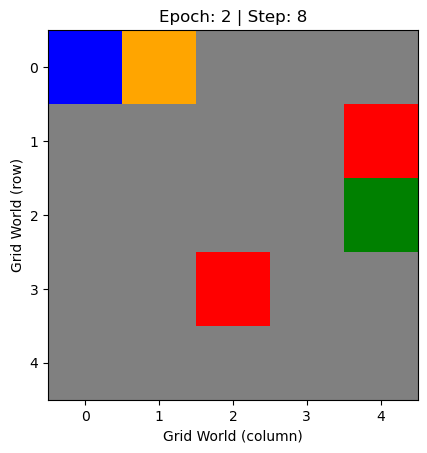

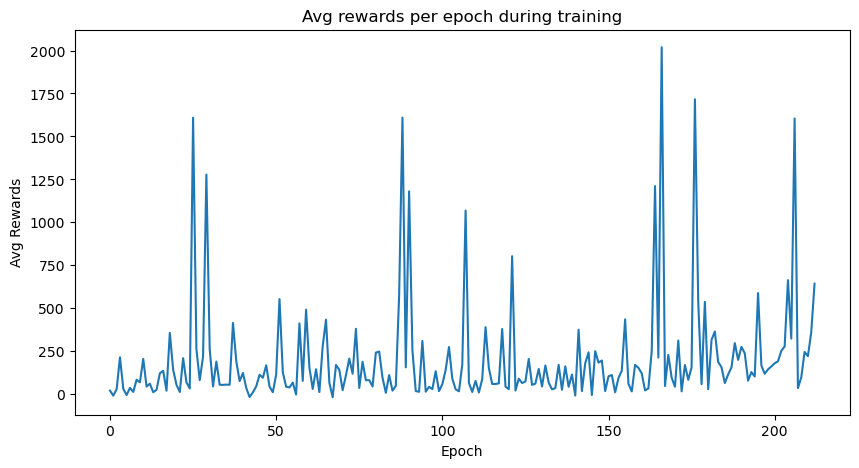

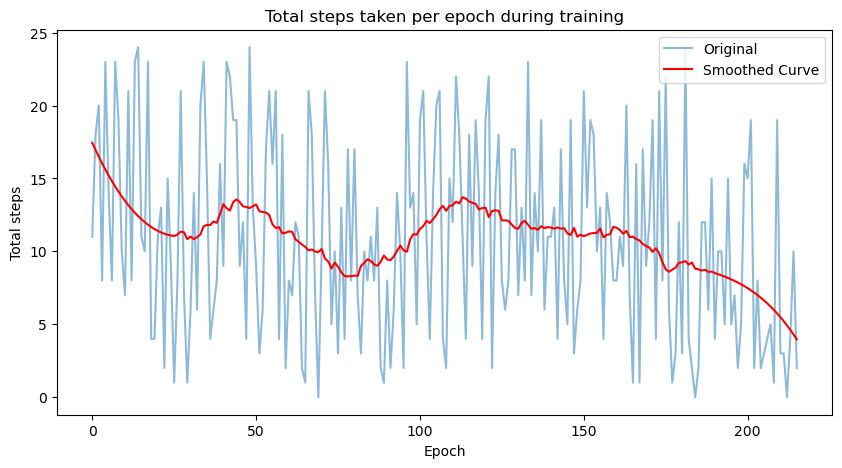

In [ ]:
%matplotlib inline
sim.plot_training_history_rewards()
sim.plot_training_history_step()
